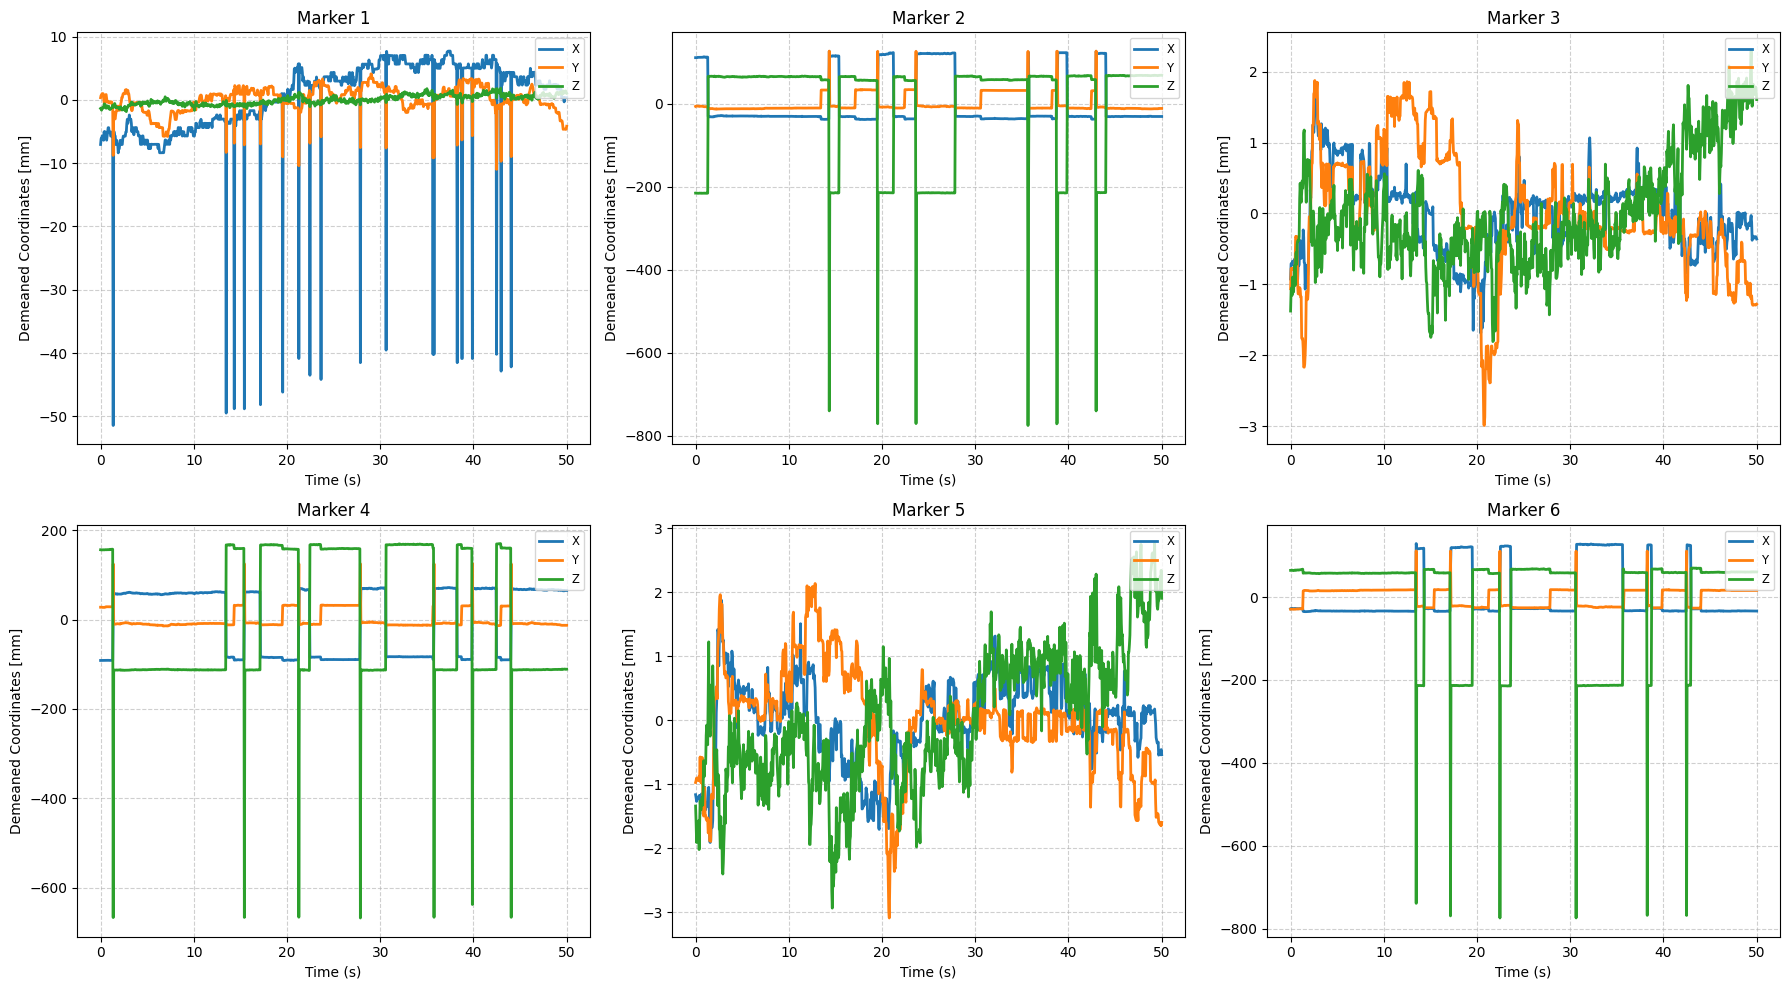

In [411]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 50, num_points)  # time axis (0–60 sec)

    ax.plot(t, data[:, 0], label='X', linewidth=2)
    ax.plot(t, data[:, 1], label='Y', linewidth=2)
    ax.plot(t, data[:, 2], label='Z', linewidth=2)

    ax.set_ylabel('Demeaned Coordinates [mm]')
    ax.set_xlabel('Time (s)')
    ax.set_title(marker_pos)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

# Extracció dels 6 markers del DataFrame
marker1 = raw_df[['pt1_x', 'pt1_y', 'pt1_z']]
marker2 = raw_df[['pt2_x', 'pt2_y', 'pt2_z']]
marker3 = raw_df[['pt3_x', 'pt3_y', 'pt3_z']]
marker4 = raw_df[['pt4_x', 'pt4_y', 'pt4_z']]
marker5 = raw_df[['pt5_x', 'pt5_y', 'pt5_z']]
marker6 = raw_df[['pt6_x', 'pt6_y', 'pt6_z']]

# Llista amb els 6 markers (pots canviar els noms com 'Marker 1' pel nom de la part del cos si vols)
markers = [
    (marker1, 'Marker 1', 'pt1'),
    (marker2, 'Marker 2', 'pt2'),
    (marker3, 'Marker 3', 'pt3'),
    (marker4, 'Marker 4', 'pt4'),
    (marker5, 'Marker 5', 'pt5'),
    (marker6, 'Marker 6', 'pt6')
]

# -------------------------
# CREATE SUBPLOTS (2 rows, 3 columns for 6 markers)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Convertim la matriu de 2x3 en una llista plana de 6 per iterar fàcilment

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']
    z = df[f'{prefix}_z']

    x_norm = x - x.mean()
    y_norm = y - y.mean()
    z_norm = z - z.mean()

    data = np.vstack((x_norm, y_norm, z_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
save_path = os.path.join(output_folder, 'markers_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()

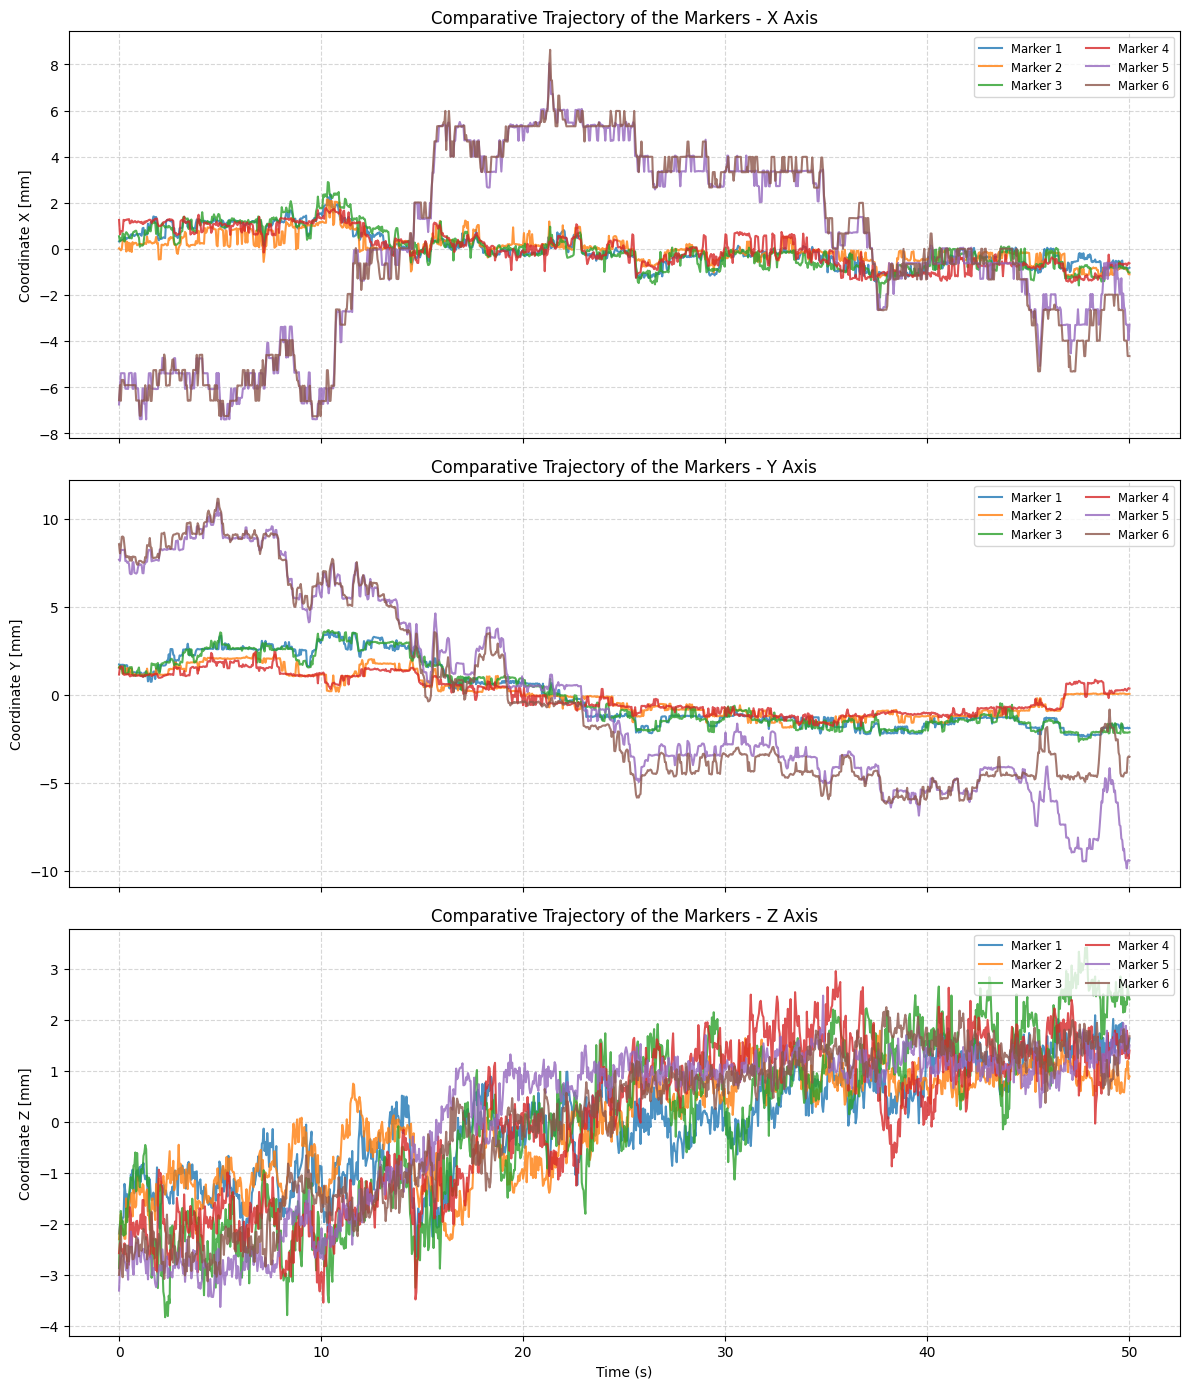

In [304]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-200].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)  # Eix de temps (0–10 segons com el teu script original)

# Definim els 6 markers i els seus colors per a que bonic i identificable
marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE SUBPLOTS (1 fila per cada eix: X, Y, Z)
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
axes_names = ["X", "Y", "Z"]

for i, axis_letter in enumerate(["x", "y", "z"]):
    ax = axes[i]

    # Iterem pels 6 marcadors per a dibuixar la seva línia en aquest eix
    for j, prefix in enumerate(marker_prefixes):
        coord = raw_df[f"{prefix}_{axis_letter}"]

        # Normalitzem (restem la mitjana) tal com feies al teu script original
        coord_norm = coord - coord.mean()

        ax.plot(
            t,
            coord_norm,
            label=f"Marker {j+1}",
            color=colors[j],
            linewidth=1.5,
            alpha=0.8,
        )

    # Configuració de cada subgràfic
    ax.set_ylabel(f"Coordinate {axes_names[i]} [mm]")
    ax.set_title(
        f"Comparative Trajectory of the Markers - {axes_names[i]} Axis"
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize="small", ncol=2)

# Configurar l'eix X final (només a l'últim gràfic gràcies a sharex=True)
axes[-1].set_xlabel("Time (s)")

plt.tight_layout()

# Guardar i mostrar el gràfic
save_path = os.path.join(output_folder, "trajectories_comparativa.png")
plt.savefig(save_path, dpi=200)
plt.show()




In [305]:
import numpy as np
import pandas as pd


input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed/transform_3d.csv"


# Carreguem el DataFrame de moviment
df_motion_raw = pd.read_csv(input_csv)

df_motion = df_motion_raw.iloc[:-200].reset_index(drop=True)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4" , "pt5", "pt6"]
axes = ["x", "y", "z"]

# Llista per guardar els resultats de cada marcador i eix
results = []

# -------------------------
# CÀLCUL DE MÈTRIQUES
# -------------------------
for j, prefix in enumerate(marker_prefixes):
    for axis in axes:
        # Dades de la gravació en moviment (g)
        motion_coord = df_motion[f"{prefix}_{axis}"]

        # POSICIÓ IDEAL = No moure's res (el valor mitjà central del mateix senyal)
        ideal_pos = motion_coord.mean()

        # 1. Desviació Estàndard (σ) -> Quant "vibra" el senyal al voltant del seu centre
        std_dev = motion_coord.std()

        # 2. RMSE (Root Mean Square Error) respecte a la posició ideal de "no moviment"
        # Com que la referència és la pròpia mitjana, l'RMSE matemàticament coincidirà
        # pràcticament amb la desviació estàndard (estem avaluant el soroll pur)
        rmse = np.sqrt(np.mean((motion_coord - ideal_pos) ** 2))

        # 3. Error Màxim (Peak-to-Peak) -> Rang total del soroll (pic a pic)
        peak_to_peak = motion_coord.max() - motion_coord.min()

        # Guardem les dades estructurades
        results.append({
            "Marker": f"Marker {j+1}",
            "Axis": axis.upper(),
            "Std Dev (σ) [mm]": round(std_dev, 4),
            "Peak-to-Peak [mm]": round(peak_to_peak, 4)
        })

# Creem el DataFrame final per mostrar-lo en format taula
metrics_df = pd.DataFrame(results)

# Mostrem la taula directament a la consola
print(metrics_df.to_string(index=False))



  Marker Axis  Std Dev (σ) [mm]  Peak-to-Peak [mm]
Marker 1    X            0.7520             3.8106
Marker 1    Y            1.8768             5.9738
Marker 1    Z            1.0655             5.4363
Marker 2    X            0.5767             3.3879
Marker 2    Y            1.1854             4.1782
Marker 2    Z            1.0491             5.2917
Marker 3    X            0.8618             5.0115
Marker 3    Y            1.8816             6.3446
Marker 3    Z            1.7511             8.6218
Marker 4    X            0.8318             3.2423
Marker 4    Y            1.0574             4.2170
Marker 4    Z            1.5881             7.0685
Marker 5    X            4.0553            16.1616
Marker 5    Y            5.4925            20.7840
Marker 5    Z            1.6383             6.7400
Marker 6    X            4.2153            17.1786
Marker 6    Y            5.3551            17.3915
Marker 6    Z            1.5074             5.8809


In [306]:
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed/transform_3d.csv"

df_motion_raw = pd.read_csv(input_csv)
df_motion = df_motion_raw.iloc[:-200].reset_index(drop=True)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
axes = ["x", "y", "z"]
results = []

for j, prefix in enumerate(marker_prefixes):
    for axis in axes:
        signal = df_motion[f"{prefix}_{axis}"].dropna()

        std_dev = signal.std()
        peak_to_peak = signal.max() - signal.min()

        # More robust than raw peak-to-peak: range between 2.5th and 97.5th percentile
        p975 = np.percentile(signal, 97.5)
        p025 = np.percentile(signal, 2.5)
        robust_range = p975 - p025

        results.append({
            "Marker": f"Marker {j+1}",
            "Axis": axis.upper(),
            "Std Dev (σ) [mm]": round(std_dev, 4),
            "Peak-to-Peak [mm]": round(peak_to_peak, 4),
        })

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))


  Marker Axis  Std Dev (σ) [mm]  Peak-to-Peak [mm]
Marker 1    X            0.7520             3.8106
Marker 1    Y            1.8768             5.9738
Marker 1    Z            1.0655             5.4363
Marker 2    X            0.5767             3.3879
Marker 2    Y            1.1854             4.1782
Marker 2    Z            1.0491             5.2917
Marker 3    X            0.8618             5.0115
Marker 3    Y            1.8816             6.3446
Marker 3    Z            1.7511             8.6218
Marker 4    X            0.8318             3.2423
Marker 4    Y            1.0574             4.2170
Marker 4    Z            1.5881             7.0685
Marker 5    X            4.0553            16.1616
Marker 5    Y            5.4925            20.7840
Marker 5    Z            1.6383             6.7400
Marker 6    X            4.2153            17.1786
Marker 6    Y            5.3551            17.3915
Marker 6    Z            1.5074             5.8809


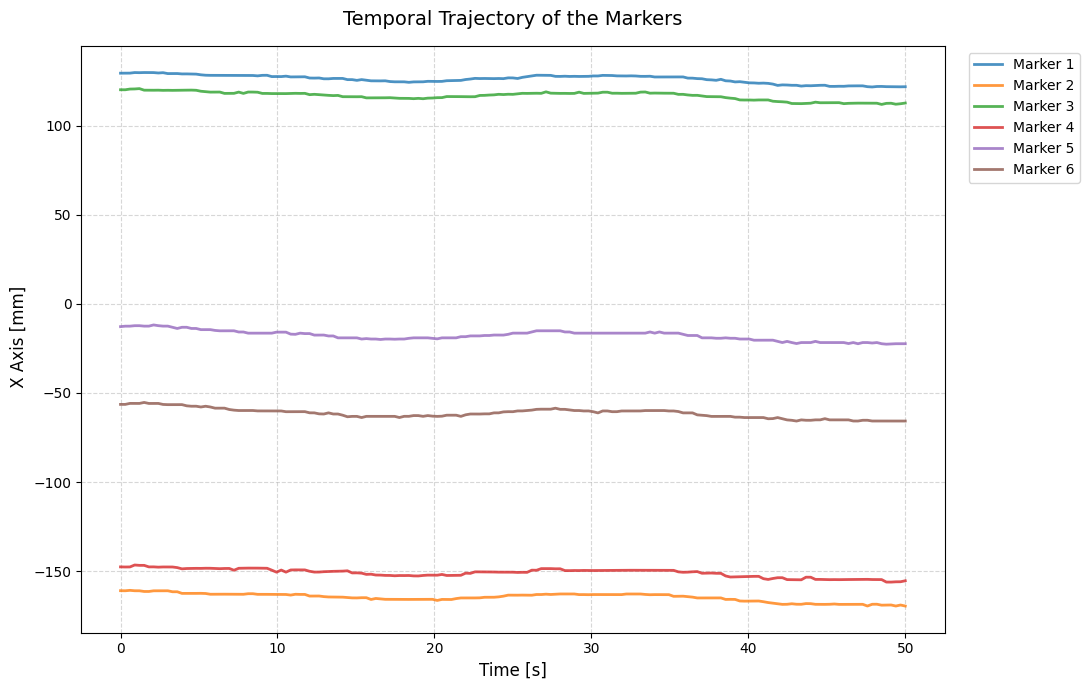

In [387]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/LUCA6/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[:-200].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(
    0, 50, num_points
)  # Temps en segons (ara va d'esquerra a dreta)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE PLOT (Temps vs Posició X)
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

# Dibuixem la trajectòria de cada marcador d'esquerra a dreta
for j, prefix in enumerate(marker_prefixes):
    # Coordenada X real (sense normalitzar per mantenir la separació física)
    x_coords = raw_df[f"{prefix}_x"]

    # Plot estàndard: Temps a la l'eix X, Posició a l'eix Y
    ax.plot(
        t,
        x_coords,
        label=f"Marker {j+1}",
        color=colors[j],
        linewidth=2,
        alpha=0.8,
    )

# -------------------------
# CONFIGURACIÓ DE L'ESTIL
# -------------------------
ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel(" X Axis [mm]", fontsize=12)
ax.set_title(
    "Temporal Trajectory of the Markers", fontsize=14, pad=15
)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(
    loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium"
)

plt.tight_layout()

# Guardar i mostrar el gràfic
save_path = os.path.join(output_folder, "trajectoria_horitzontal_X.png")
plt.savefig(save_path, dpi=200)
plt.show()

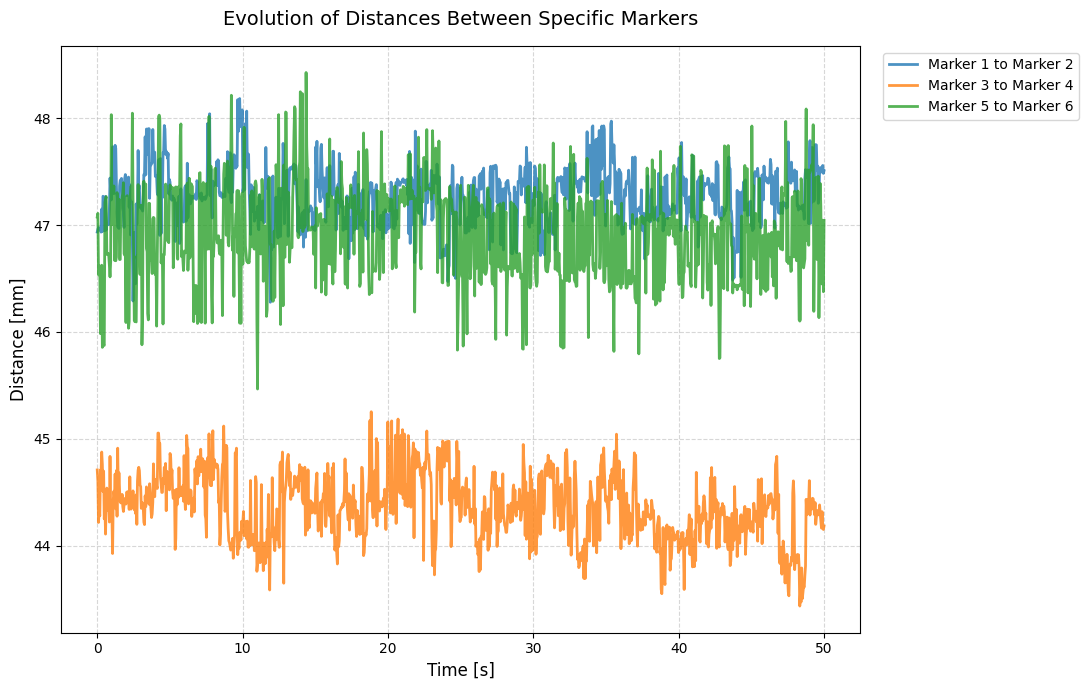

In [309]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona1/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/q/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[:-200].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)  # Time in seconds


# Helper function to calculate 3D Euclidean distance between two markers
def calculate_distance(df, marker_a, marker_b):
    dx = df[f"{marker_a}_x"] - df[f"{marker_b}_x"]
    dy = df[f"{marker_a}_y"] - df[f"{marker_b}_y"]
    dz = df[f"{marker_a}_z"] - df[f"{marker_b}_z"]
    return np.sqrt(dx ** 2 + dy ** 2 + dz ** 2)


# -------------------------
# CALCULATE DISTANCES
# -------------------------
# Difference between markers 1 and 2
dist_1_2 = calculate_distance(raw_df, "pt1", "pt3")

# Difference between markers 3 and 6
dist_3_6 = calculate_distance(raw_df, "pt2", "pt4")

# Difference between markers 4 and 5
dist_4_5 = calculate_distance(raw_df, "pt5", "pt6")

# -------------------------
# CREATE PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

# Plotting the distance curves
ax.plot(t, dist_1_2, label="Marker 1 to Marker 2", color="#1f77b4", linewidth=2, alpha=0.8)
ax.plot(t, dist_3_6, label="Marker 3 to Marker 4", color="#ff7f0e", linewidth=2, alpha=0.8)
ax.plot(t, dist_4_5, label="Marker 5 to Marker 6", color="#2ca02c", linewidth=2, alpha=0.8)

# -------------------------
# STYLE CONFIGURATION
# -------------------------
ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel("Distance [mm]", fontsize=12)
ax.set_title("Evolution of Distances Between Specific Markers", fontsize=14, pad=15)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium")

plt.tight_layout()

# Save and show the plot
save_path = os.path.join(output_folder, "marker_distances_over_time.png")
plt.savefig(save_path, dpi=200)
plt.show()

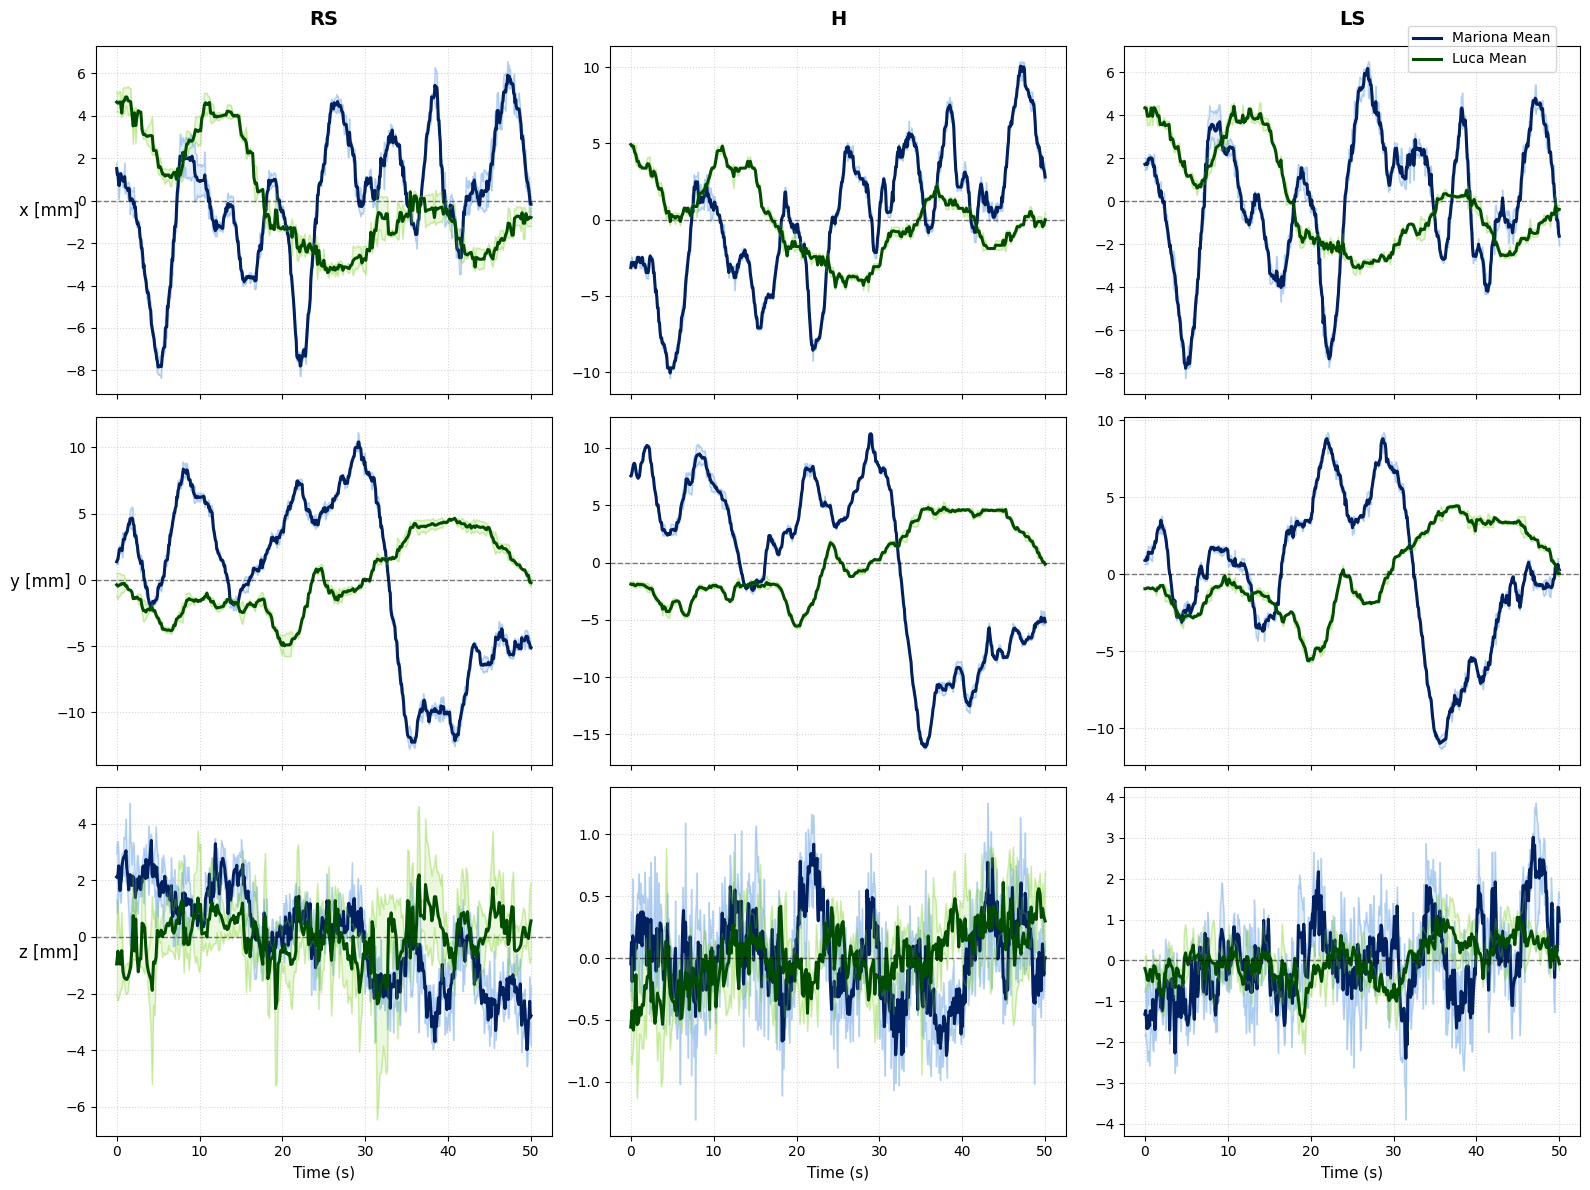

In [366]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# FILE PATH CONFIGURATIONS
# -------------------------
mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona6/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca6/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR CALCULATIONS
# -------------------------
def process_recording_data(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[20:-20].reset_index(drop=True)

    num_points = df.shape[0]
    t_axis = np.linspace(0, 50, num_points)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        results[part] = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            # Center data around 0
            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            mean_profile = (coord1_norm + coord2_norm) / 2
            std_profile = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

            results[part][axis] = {
                "mean": mean_profile,
                "std": std_profile
            }

    return t_axis, results

# Process both datasets
t_mariona, mariona_data = process_recording_data(mariona_csv, mariona_pairs)
t_luca, luca_data = process_recording_data(luca_csv, luca_pairs)

# -------------------------
# INITIALIZE 3x3 PLOT GRID
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)

part_keys = ["RS", "H", "LS"]
axes_letters = ["x", "y", "z"]

# New requested color definitions
mariona_mean_color = "#002060"   # Dark Blue
mariona_std_color = "#4a90e2"    # Light Blue
luca_mean_color = "#004d00"      # Dark Green
luca_std_color = "#7ed321"       # Light Green

for row_idx, axis_letter in enumerate(axes_letters):
    for col_idx, part in enumerate(part_keys):
        ax = axes[row_idx, col_idx]

        # 1. PLOT MARIONA1 DATA
        m_stats = mariona_data[part][axis_letter]
        m_mean = m_stats["mean"]
        m_std = m_stats["std"]

        m_upper = m_mean + m_std
        m_lower = m_mean - m_std

        # Error bounds and fill
        ax.plot(t_mariona, m_upper, color=mariona_std_color, alpha=0.3, linewidth=1)
        ax.plot(t_mariona, m_lower, color=mariona_std_color, alpha=0.3, linewidth=1)
        ax.fill_between(t_mariona, m_lower, m_upper, color=mariona_std_color, alpha=0.15)

        # Mean profile line
        ax.plot(
            t_mariona, m_mean,
            color=mariona_mean_color, linewidth=2.2,
            label="Mariona Mean" if (row_idx == 0 and col_idx == 0) else ""
        )

        # 2. OVERLAY LUCA1 DATA
        l_stats = luca_data[part][axis_letter]
        l_mean = l_stats["mean"]
        l_std = l_stats["std"]

        l_upper = l_mean + l_std
        l_lower = l_mean - l_std

        # Error bounds and fill
        ax.plot(t_luca, l_upper, color=luca_std_color, alpha=0.3, linewidth=1)
        ax.plot(t_luca, l_lower, color=luca_std_color, alpha=0.3, linewidth=1)
        ax.fill_between(t_luca, l_lower, l_upper, color=luca_std_color, alpha=0.15)

        # Mean profile line
        ax.plot(
            t_luca, l_mean,
            color=luca_mean_color, linewidth=2.2,
            label="Luca Mean" if (row_idx == 0 and col_idx == 0) else ""
        )

        # 3. SUBPLOT STYLING
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

        if row_idx == 0:
            ax.set_title(part, fontsize=14, fontweight="bold", pad=15)

        if col_idx == 0:
            ax.set_ylabel(f"{axis_letter} [mm]", fontsize=12, labelpad=12, rotation=0)

        ax.grid(True, linestyle=":", alpha=0.5)

# Label shared timeline
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)", fontsize=11)

# Combined legend position
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize="medium")

plt.tight_layout()

# Save final overlay image matrix
save_path = os.path.join(output_folder, "motion_profiles_overlay_final.png")
plt.savefig(save_path, dpi=200)
plt.show()

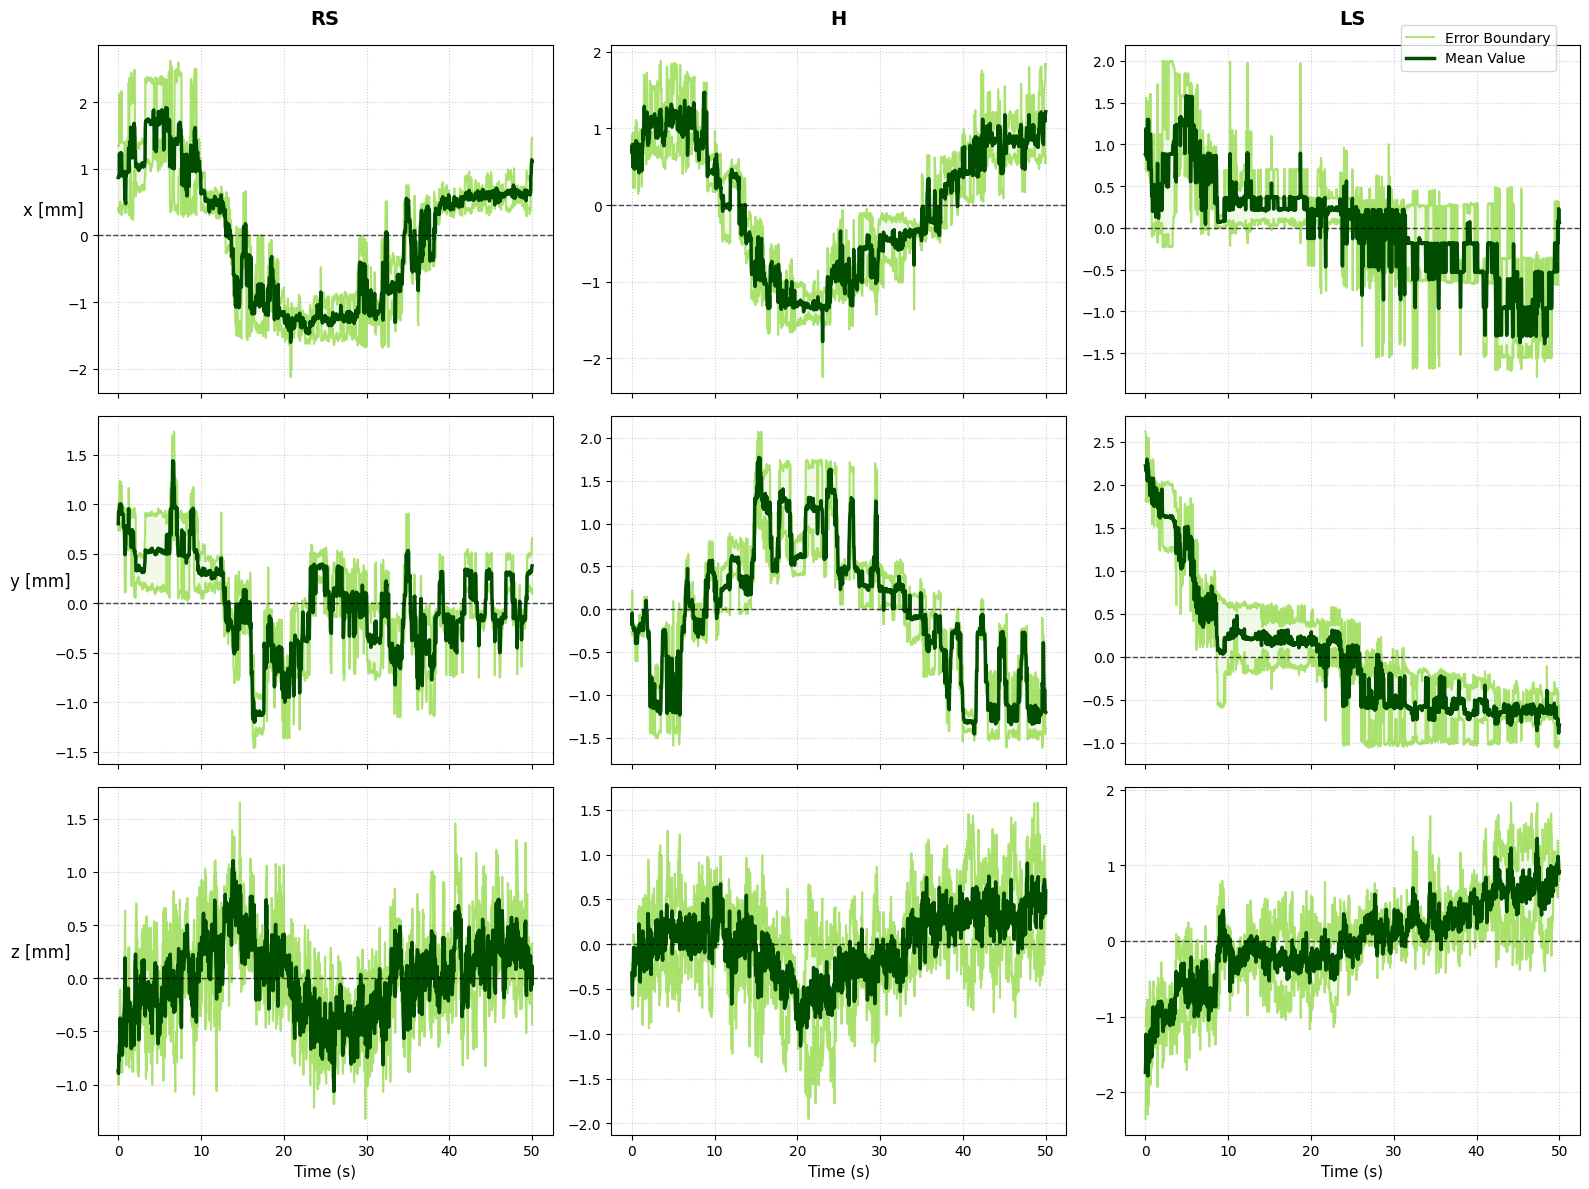

In [412]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca2/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)  # 50 seconds time axis

# Define the structures and their corresponding vertical marker pairs from your setup
body_parts = {
    "RS": ("pt2", "pt6"),  # Right Shoulder
    "H": ("pt1", "pt5"),  # Head
    "LS": ("pt3", "pt4"),  # Left Shoulder
}
part_keys = ["RS", "H", "LS"]
axes_letters = ["x", "y", "z"]

# -------------------------
# INITIALIZE 3x3 PLOT GRID
# -------------------------
# sharex=True ensures all subplots align vertically with the time axis
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)

# Style configuration
mean_color = "#004d00"  # Pinkish line for the mean value
std_color = "#7ed321"  # Blueish area/line for the standard deviation/error

for row_idx, axis_letter in enumerate(axes_letters):
    for col_idx, part in enumerate(part_keys):
        ax = axes[row_idx, col_idx]

        m1, m2 = body_parts[part]

        # Extract coordinates for the two markers
        coord1 = raw_df[f"{m1}_{axis_letter}"]
        coord2 = raw_df[f"{m2}_{axis_letter}"]

        # Normalize individual markers to their respective means
        coord1_norm = coord1 - coord1.mean()
        coord2_norm = coord2 - coord2.mean()

        # 1. Compute Mean profile over time
        mean_profile = (coord1_norm + coord2_norm) / 2

        # 2. Compute Standard Deviation profile at each time point
        # Using ddof=1 for sample standard dev; np.std works element-wise across the pairs
        std_profile = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

        # Plot error range/stdev boundaries (The blue curves)
        upper_bound = mean_profile + std_profile
        lower_bound = mean_profile - std_profile

        # Optional: Plot the standard deviation line boundaries (like the blue line in your image)
        ax.plot(
            t,
            upper_bound,
            color=std_color,
            alpha=0.6,
            linewidth=1.5,
            label="Error Boundary" if (row_idx == 0 and col_idx == 0) else "",
        )
        ax.plot(t, lower_bound, color=std_color, alpha=0.6, linewidth=1.5)

        # Fill the error range between standard deviations
        ax.fill_between(t, lower_bound, upper_bound, color=std_color, alpha=0.1)

        # Plot the main center mean value line (The pink curve)
        ax.plot(
            t,
            mean_profile,
            color=mean_color,
            linewidth=2.5,
            label="Mean Value" if (row_idx == 0 and col_idx == 0) else "",
        )

        # Reference zero line (dashed black line)
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

        # Formatting titles only on the top row blocks
        if row_idx == 0:
            ax.set_title(part, fontsize=14, fontweight="bold", pad=15)

        # Formatting Y labels only on the first column blocks
        if col_idx == 0:
            ax.set_ylabel(
                f"{axis_letter} [mm]", fontsize=12, labelpad=10, rotation=0
            )

        ax.grid(True, linestyle=":", alpha=0.6)

# Label the shared X axis across the bottom subplots
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)", fontsize=11)

# Single global legend at the upper center position of the window layout
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize="medium")

plt.tight_layout()

# Save and render final image matrix
save_path = os.path.join(output_folder, "motion_profiles_matrix.png")
plt.savefig(save_path, dpi=200)
plt.show()

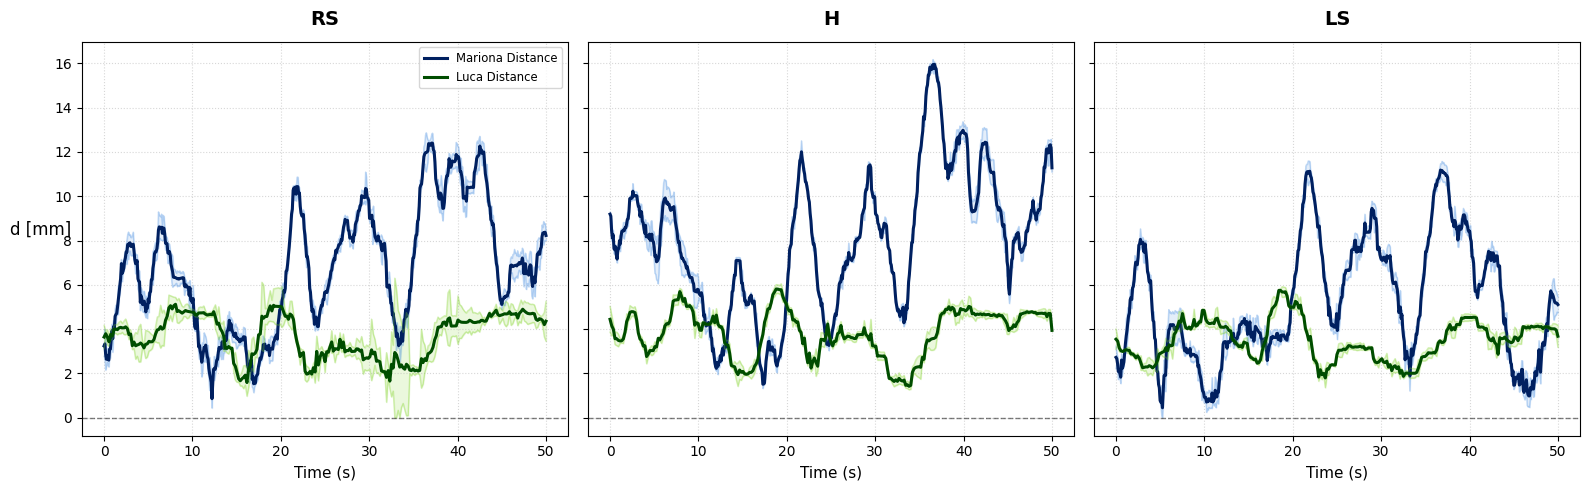

In [388]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# FILE PATH CONFIGURATIONS
# -------------------------
mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona6/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca6/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt4", "pt2"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR METRICS
# -------------------------
def process_euclidean_metrics(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[50:-50].reset_index(drop=True)

    num_points = df.shape[0]
    t_axis = np.linspace(0, 50, num_points)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        # 1. Compute normalized mean and std for each axis
        motion_data = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            motion_data[f"{axis}_mean"] = (coord1_norm + coord2_norm) / 2
            motion_data[f"{axis}_std"] = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

        # 2. Compute Euclidean Distance (d) from origin
        x = motion_data["x_mean"]
        y = motion_data["y_mean"]
        z = motion_data["z_mean"]

        d = np.sqrt(x**2 + y**2 + z**2)

        # 3. Propagate Standard Deviation (sigma_d)
        sig_x = motion_data["x_std"]
        sig_y = motion_data["y_std"]
        sig_z = motion_data["z_std"]

        # To avoid potential division by zero if d is exactly 0
        safe_d = np.where(d == 0, 1e-6, d)

        sigma_d = np.sqrt((x * sig_x)**2 + (y * sig_y)**2 + (z * sig_z)**2) / safe_d

        results[part] = {
            "d": d,
            "sigma_d": sigma_d
        }

    return t_axis, results

# Process metrics for both participants
t_mariona, mariona_dist = process_euclidean_metrics(mariona_csv, mariona_pairs)
t_luca, luca_dist = process_euclidean_metrics(luca_csv, luca_pairs)

# -------------------------
# PLOT DISTANCES (1x3 Row Layout)
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
part_keys = ["RS", "H", "LS"]  # Matching horizontal layout order

# Style color palette
mariona_mean_color = "#002060"   # Dark Blue
mariona_std_color = "#4a90e2"    # Light Blue
luca_mean_color = "#004d00"      # Dark Green
luca_std_color = "#7ed321"       # Light Green

for idx, part in enumerate(part_keys):
    ax = axes[idx]

    # --- Plot Mariona ---
    m_d = mariona_dist[part]["d"]
    m_sig = mariona_dist[part]["sigma_d"]

    m_upper = m_d + m_sig
    m_lower = np.maximum(0, m_d - m_sig)  # Distance cannot drop below absolute zero

    ax.plot(t_mariona, m_upper, color=mariona_std_color, alpha=0.3, linewidth=1)
    ax.plot(t_mariona, m_lower, color=mariona_std_color, alpha=0.3, linewidth=1)
    ax.fill_between(t_mariona, m_lower, m_upper, color=mariona_std_color, alpha=0.15)
    ax.plot(t_mariona, m_d, color=mariona_mean_color, linewidth=2.2, label="Mariona Distance")

    # --- Plot Luca ---
    l_d = luca_dist[part]["d"]
    l_sig = luca_dist[part]["sigma_d"]

    l_upper = l_d + l_sig
    l_lower = np.maximum(0, l_d - l_sig)

    ax.plot(t_luca, l_upper, color=luca_std_color, alpha=0.3, linewidth=1)
    ax.plot(t_luca, l_lower, color=luca_std_color, alpha=0.3, linewidth=1)
    ax.fill_between(t_luca, l_lower, l_upper, color=luca_std_color, alpha=0.15)
    ax.plot(t_luca, l_d, color=luca_mean_color, linewidth=2.2, label="Luca Distance")

    # --- Custom Plot Styling ---
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(part, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.5)

    if idx == 0:
        ax.set_ylabel("d [mm]", fontsize=12, labelpad=10, rotation=0)

# Single unified legend
axes[0].legend(loc="upper right", fontsize="small")

plt.tight_layout()

# Save final distance image matrix
save_path = os.path.join(output_folder, "euclidean_distances_comparison.png")
plt.savefig(save_path, dpi=200)
plt.show()

In [402]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# FILE PATH CONFIGURATIONS
# -------------------------
mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona6/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca6/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt4", "pt2"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR EXTRACTION
# -------------------------
def process_recording_data(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[50:-50].reset_index(drop=True)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        results[part] = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            # Center data around 0
            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            # The standard deviation profile represents the error (d_t) at each time frame
            std_profile = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

            results[part][axis] = std_profile

    return results

# -------------------------
# METRIC CALCULATION FUNCTION
# -------------------------
def calculate_metrics(data_dict):
    """
    Calculates overall MAE and RMSE across all time steps (N) and all 3 spatial axes
    for each anatomical position.
    """
    metrics_summary = {}

    for part, axes_data in data_dict.items():
        # Combine all standard deviation values (d_t) across x, y, and z axes into one flat array
        all_d_t = np.concatenate([axes_data["x"], axes_data["y"], axes_data["z"]])

        # Calculate MAE: Mean of absolute values (since d_t is std, it's already positive)
        mae_val = np.mean(np.abs(all_d_t))

        # Calculate RMSE: Square root of the mean of squared values
        rmse_val = np.sqrt(np.mean(all_d_t**2))

        metrics_summary[part] = {
            "MAE": mae_val,
            "RMSE": rmse_val
        }

    return metrics_summary

# -------------------------
# EXECUTION & DATA PROCESSING
# -------------------------
# Extract profiles
mariona_profiles = process_recording_data(mariona_csv, mariona_pairs)
luca_profiles = process_recording_data(luca_csv, luca_pairs)

# Compute MAE and RMSE
mariona_metrics = calculate_metrics(mariona_profiles)
luca_metrics = calculate_metrics(luca_profiles)

# -------------------------
# COMPILE AND SAVE RESULTS
# -------------------------
rows = []
for part in ["RS", "H", "LS"]:
    rows.append({
        "Volunteer": "Mariona",
        "Anatomical Position": part,
        "MAE": mariona_metrics[part]["MAE"],
        "RMSE": mariona_metrics[part]["RMSE"]
    })
for part in ["RS", "H", "LS"]:
    rows.append({
        "Volunteer": "Luca",
        "Anatomical Position": part,
        "MAE": luca_metrics[part]["MAE"],
        "RMSE": luca_metrics[part]["RMSE"]
    })

# Convert to DataFrame for elegant printing and saving
summary_df = pd.DataFrame(rows)

# Print Summary table to console
print("\n" + "="*50)
print("             RECORDING ERROR METRICS")
print("="*50)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*50)

# Export metrics summary to a CSV file
csv_save_path = os.path.join(output_folder, "error_metrics_summary.csv")
summary_df.to_csv(csv_save_path, index=False)


             RECORDING ERROR METRICS
Volunteer Anatomical Position    MAE   RMSE
  Mariona                  RS 0.4061 0.5249
  Mariona                   H 0.2562 0.3277
  Mariona                  LS 0.3556 0.4772
     Luca                  RS 0.5472 0.7854
     Luca                   H 0.1892 0.2338
     Luca                  LS 0.2137 0.2844


In [404]:
import os
import numpy as np
import pandas as pd

# -------------------------
# CONFIGURACIÓ DE RUTES DE FITXERS
# -------------------------
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca6/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# CONFIGURACIÓ DELS MARCADORS EN EL LUCA
# -------------------------
luca_pairs = {
    "LS": ("pt2", "pt6"),
    "RS": ("pt3", "pt4"),
    "H":  ("pt1", "pt5")
}

# -------------------------
# FUNCIÓ AUXILIAR PER PROCESSAR LES DADES
# -------------------------
def process_recording_data(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[20:-20].reset_index(drop=True)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        results[part] = {}
        for axis in axes_letters:
            col1 = f"{m1}_{axis}"
            col2 = f"{m2}_{axis}"

            # Comprovació de seguretat: si la columna no existeix al CSV, omplim amb NaNs
            if col1 not in df.columns or col2 not in df.columns:
                results[part][axis] = np.array([])
                continue

            coord1 = df[col1]
            coord2 = df[col2]

            # Centrem les dades al voltant de 0 ignorent els NaNs si n'hi hagués
            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            # Calculem la desviació estàndard (la d_t del gràfic) a cada instant de temps
            # Utilitzem nanstd per evitar que un sol NaN espatlli tot el perfil
            std_profile = np.nanstd([coord1_norm, coord2_norm], axis=0, ddof=1)

            results[part][axis] = std_profile

    return results

# -------------------------
# FUNCIÓ PER CALCULAR LES MÈTRIQUES (MAE i RMSE)
# -------------------------
def calculate_metrics(data_dict):
    metrics_summary = {}

    for part, axes_data in data_dict.items():
        # Combinem els valors d_t dels 3 eixos (x, y, z) en una sola llista plana
        all_d_ts = []
        for axis in ["x", "y", "z"]:
            if len(axes_data[axis]) > 0:
                all_d_ts.append(axes_data[axis])

        if len(all_d_ts) == 0:
            metrics_summary[part] = {"MAE": np.nan, "RMSE": np.nan}
            continue

        all_d_t = np.concatenate(all_d_ts)

        # Eliminem valors nuls abans de fer les operacions matemàtiques
        all_d_t = all_d_t[~np.isnan(all_d_t)]

        if len(all_d_t) == 0:
            metrics_summary[part] = {"MAE": np.nan, "RMSE": np.nan}
            continue

        # MAE: Mitjana dels valors absoluts (com que d_t és std, ja és positiu)
        mae_val = np.mean(np.abs(all_d_t))

        # RMSE: Arrel quadrada de la mitjana dels valors al quadrat
        rmse_val = np.sqrt(np.mean(all_d_t**2))

        metrics_summary[part] = {
            "MAE": mae_val,
            "RMSE": rmse_val
        }

    return metrics_summary

# -------------------------
# EXECUCIÓ DEL CÀLCUL
# -------------------------
# Extreure perfils del Luca
luca_profiles = process_recording_data(luca_csv, luca_pairs)

# Calcular MAE i RMSE del Luca
luca_metrics = calculate_metrics(luca_profiles)

# -------------------------
# CREACIÓ DE LA TAULA I DESA DES DE RESULTATS
# -------------------------
rows = []
for part in ["RS", "H", "LS"]:
    rows.append({
        "Volunteer": "Luca",
        "Anatomical Position": part,
        "MAE": luca_metrics[part]["MAE"],
        "RMSE": luca_metrics[part]["RMSE"]
    })

# Convertir a DataFrame per mostrar-ho netament
summary_df = pd.DataFrame(rows)

# Imprimir la taula a la consola
print("\n" + "="*50)
print("         RECORDING ERROR METRICS")
print("="*50)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*50)



         RECORDING ERROR METRICS
Volunteer Anatomical Position    MAE   RMSE
     Luca                  RS 0.5768 0.7667
     Luca                   H 0.4575 0.5722
     Luca                  LS 0.4363 0.5524
Mètriques guardades correctament a:
  /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/error_metrics_luca.csv



Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_1.png


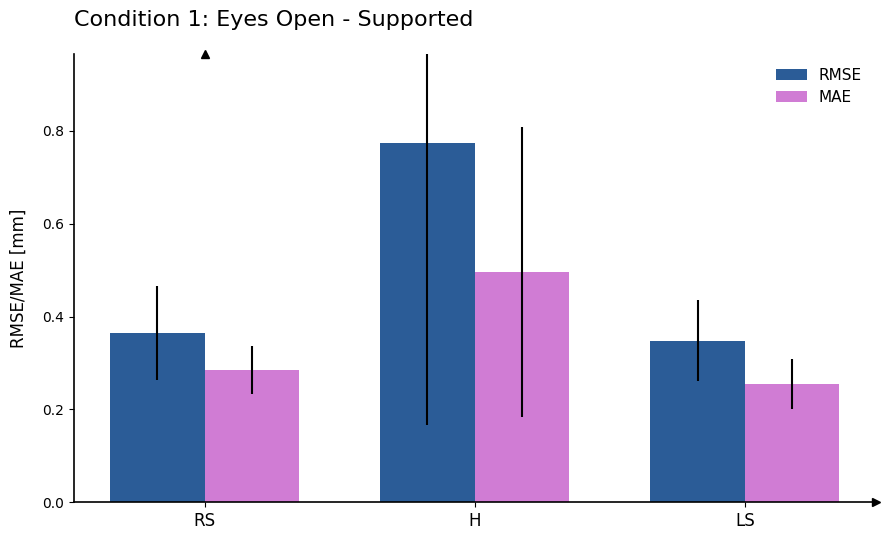

Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_2.png


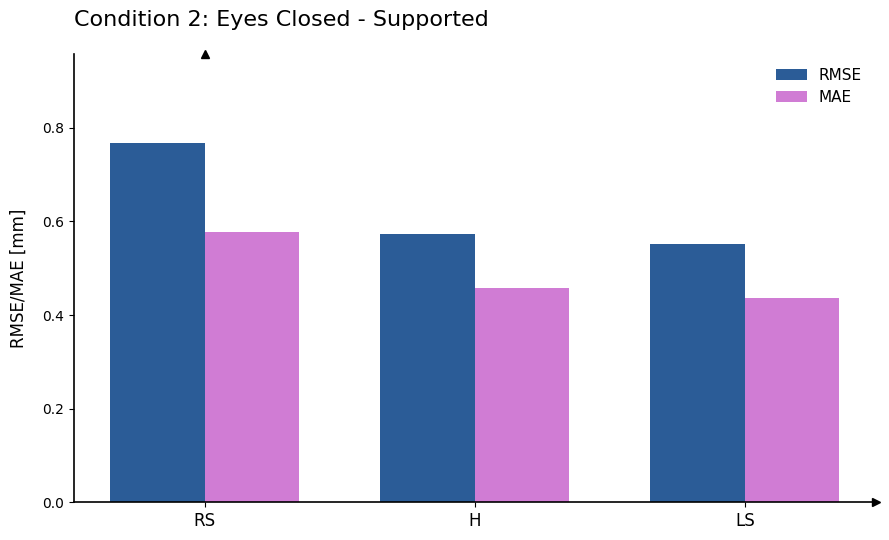

Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_3.png


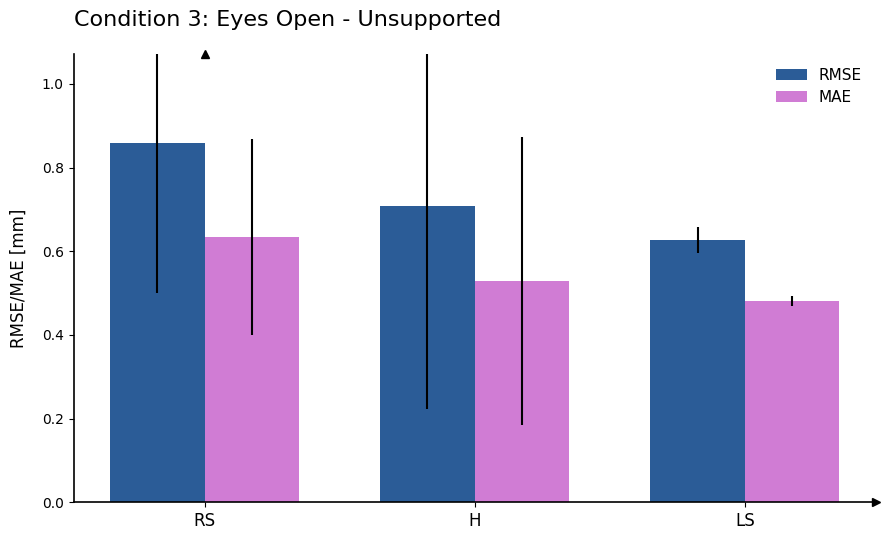

Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_4.png


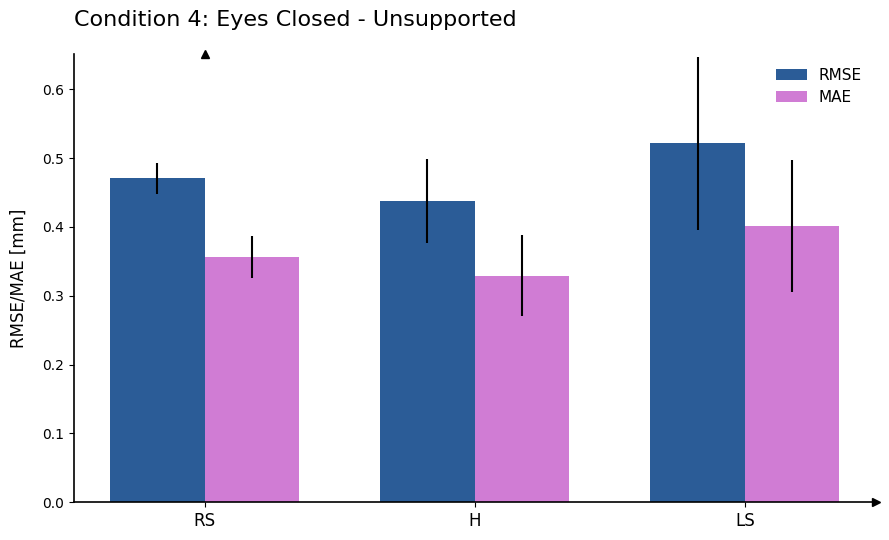

Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_5.png


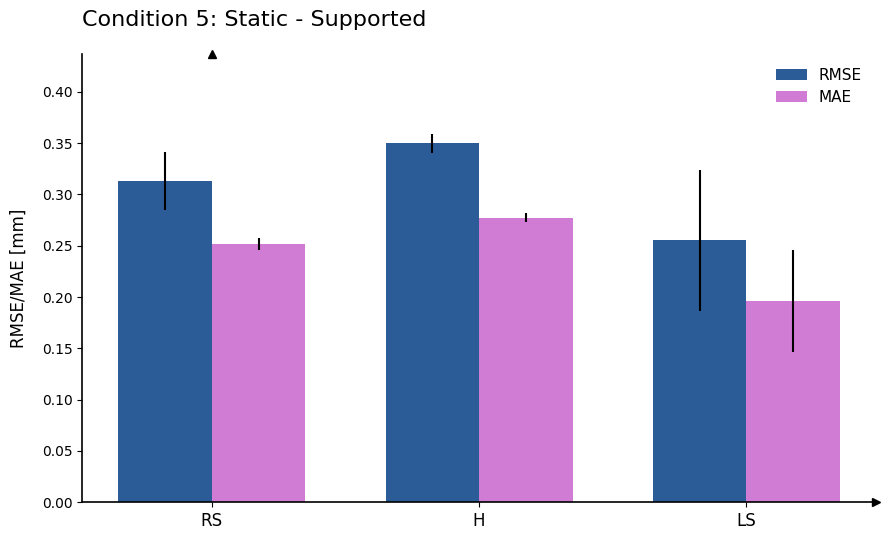

Gràfic guardat correctament a: /Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed/comparison_condition_6.png


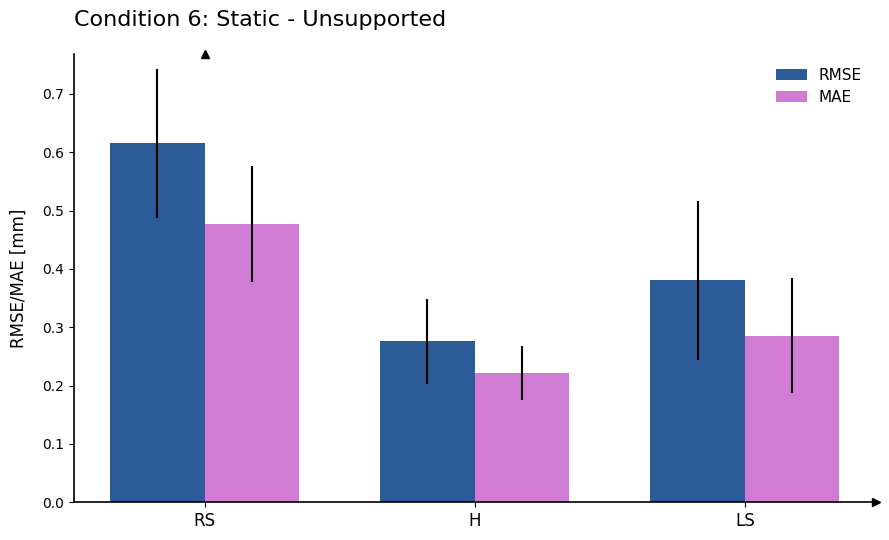

In [413]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. INTRODUCCIÓ DE LES DADES DIRECTAMENT DES DE LES TEVES CAPTURES DE PANTALLA
# ---------------------------------------------------------------------------
data_records = [
    # Condició 1: EYES OPEN SUPPORTED
    {"Condition": 1, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.3213, "RMSE": 0.4368},
    {"Condition": 1, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.7165, "RMSE": 1.2017},
    {"Condition": 1, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.2937, "RMSE": 0.4102},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.2474, "RMSE": 0.2933},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.2745, "RMSE": 0.3434},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.2173, "RMSE": 0.2862},

    # Condició 2: EYES CLOSED SUPPORTED
    {"Condition": 2, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.5768, "RMSE": 0.7667},
    {"Condition": 2, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.4575, "RMSE": 0.5722},
    {"Condition": 2, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.4363, "RMSE": 0.5524},

    # Condició 3: EYES OPEN UNSUPPORTED
    {"Condition": 3, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.4685, "RMSE": 0.6051},
    {"Condition": 3, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2860, "RMSE": 0.3653},
    {"Condition": 3, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.4901, "RMSE": 0.6497},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.7997, "RMSE": 1.1102},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.7715, "RMSE": 1.0499},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.4724, "RMSE": 0.6053},

    # Condició 4: EYES CLOSED UNSUPPORTED
    {"Condition": 4, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.3351, "RMSE": 0.4545},
    {"Condition": 4, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2875, "RMSE": 0.3943},
    {"Condition": 4, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.4692, "RMSE": 0.6102},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.3774, "RMSE": 0.4868},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.3713, "RMSE": 0.4806},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.3336, "RMSE": 0.4322},

    # Condició 5: STATIC SUPPORTED
    {"Condition": 5, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.2556, "RMSE": 0.3335},
    {"Condition": 5, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2804, "RMSE": 0.3560},
    {"Condition": 5, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.2316, "RMSE": 0.3041},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.2474, "RMSE": 0.2933},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.2745, "RMSE": 0.3434},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.1613, "RMSE": 0.2064},

    # Condició 6: STATIC UNSUPPORTED
    {"Condition": 6, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.4063, "RMSE": 0.5249},
    {"Condition": 6, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2542, "RMSE": 0.3277},
    {"Condition": 6, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.3555, "RMSE": 0.4772},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.5472, "RMSE": 0.7054},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.1892, "RMSE": 0.2238},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.2157, "RMSE": 0.2844},
]

df = pd.DataFrame(data_records)

# Mapeig de noms de condicions per als títols i fitxers
condition_titles = {
    1: "Eyes Open - Supported",
    2: "Eyes Closed - Supported",
    3: "Eyes Open - Unsupported",
    4: "Eyes Closed - Unsupported",
    5: "Static - Supported",
    6: "Static - Unsupported"
}

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# ---------------------------------------------------------------------------
# 2. BUCLE PER GENERAR UN GRÀFIC PER A CADA CONDICIÓ
# ---------------------------------------------------------------------------
positions = ["RS", "H", "LS"]
width = 0.35
color_rmse = "#2b5c97"
color_mae = "#d07cd4"

for cond_id in sorted(df["Condition"].unique()):
    # Filtrar dades només per a la condició actual
    cond_df = df[df["Condition"] == cond_id]

    # Agrupar per Posició (calcula la mitjana si hi ha dos voluntaris, o manté la d'un si només hi és el Luca)
    summary = cond_df.groupby("Position").agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std")
    ).reindex(positions)

    # Nota: Si una condició només té un voluntari (com la condició 2), la desviació estàndard (std)
    # donarà NaN de manera natural. Ho omplim amb 0 per evitar que doni problemes visuals.
    summary = summary.fillna(0)

    # Inicialitzar el gràfic individual
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(len(positions))

    # Dibuixar les barres de RMSE amb error_bars si n'hi ha
    ax.bar(
        x - width/2, summary["RMSE_mean"], width,
        yerr=summary["RMSE_std"], label="RMSE",
        color=color_rmse, edgecolor="none", error_kw={"ecolor": "black", "linewidth": 1.5}
    )

    # Dibuixar les barres de MAE amb error_bars si n'hi ha
    ax.bar(
        x + width/2, summary["MAE_mean"], width,
        yerr=summary["MAE_std"], label="MAE",
        color=color_mae, edgecolor="none", error_kw={"ecolor": "black", "linewidth": 1.5}
    )

    # Estilització del gràfic ajustat per condició
    title_text = f"Condition {cond_id}: {condition_titles[cond_id]}"
    ax.set_title(title_text, fontsize=16, pad=20, fontweight="regular", loc="left")
    ax.set_ylabel("RMSE/MAE [mm]", fontsize=12, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(positions, fontsize=12)

    # Estil minimalista sense línies superiors ni dretes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # Simular les fletxes als extrems del gràfic original
    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.legend(frameon=False, fontsize=11, loc="upper right")

    # Ajustar l'eix Y per deixar una mica de marge superior per sobre de la barra més alta
    max_val = max(summary["RMSE_mean"].max(), summary["MAE_mean"].max())
    ax.set_ylim(0, max_val * 1.25)

    plt.tight_layout()

    # Desar cada gràfic amb un nom únic basat en la condició
    file_name = f"comparison_condition_{cond_id}.png"
    save_path = os.path.join(output_folder, file_name)
    plt.savefig(save_path, dpi=300)

    print(f"Gràfic guardat correctament a: {save_path}")
    plt.show()
    plt.close()  # Tancar el gràfic actiu per estalviar memòria del sistema